In [4]:
import numpy as np
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

In [2]:
# This is a small dataset: Should we play tennis?
# Features: [Outlook, Temperature, Humidity, Wind]
# Outlook: 0=Sunny, 1=Overcast, 2=Rain
# Temperature: 0=Hot, 1=Mild, 2=Cool
# Humidity: 0=High, 1=Normal
# Wind: 0=Weak, 1=Strong
# Target (Play): 0=No, 1=Yes

data = [
    [0, 0, 0, 0, 0],  # Sunny, Hot, High, Weak -> No
    [0, 0, 0, 1, 0],  # Sunny, Hot, High, Strong -> No
    [1, 0, 0, 0, 1],  # Overcast, Hot, High, Weak -> Yes
    [2, 1, 0, 0, 1],  # Rain, Mild, High, Weak -> Yes
    [2, 2, 1, 0, 1],  # Rain, Cool, Normal, Weak -> Yes
    [2, 2, 1, 1, 0],  # Rain, Cool, Normal, Strong -> No
    [1, 2, 1, 1, 1],  # Overcast, Cool, Normal, Strong -> Yes
    [0, 1, 0, 0, 0],  # Sunny, Mild, High, Weak -> No
    [0, 2, 1, 0, 1],  # Sunny, Cool, Normal, Weak -> Yes
    [2, 1, 1, 0, 1],  # Rain, Mild, Normal, Weak -> Yes
]


## Helper functions (Entropy, Split, etc.)

In [8]:
def entropy(y):
  """Measures how mixed the labels are.
  y is a list of target values (0s and 1s)"""

  counts = Counter(y) # Count how many 0s and 1s
  total = len(y)

  entropy = 0
  for count in counts.values():
    p = count/total

    if p > 0:
      entropy = entropy - p*np.log2(p)

  return entropy

In [9]:
def split_dataset(X, y, feature_index, value):
  """Splits the dataset into two parts based on a feature:
  X is a 2D array of features
  y is a list of target values (0s and 1s)
  feature_index is the index of the feature to split on
  value is the value of the feature to split

  left = rows where the feature is equal to value
  right = rows where the feature is not equal to value"""

  left_X, left_y, right_X, right_y = [], [], [], []
  for i in range(len(X)):
    if X[i][feature_index] == value:
      left_X.append(X[i])
      left_y.append(y[i])

    else:
      right_X.append(X[i])
      right_y.append(y[i])

  return left_X, left_y, right_X, right_y

In [10]:
def information_gain(X, y, feature_index, value):
  """Measures how much information is gained by splitting on a feature.
  X is a 2D array of features
  y is a list of target values (0s and 1s)"""

  total_entropy = entropy(y)

  left_X, left_y, right_X, right_y = split_dataset(X, y, feature_index, value)

  if len(left_y) == 0 or len(right_y) == 0:
        return 0  # Useless split

  # Weighted average of child entropies
  n = len(y)
  child_entropy = (len(left_y)/n)*entropy(left_y) + (len(right_y)/n)* entropy(right_y)

  return total_entropy - child_entropy

## Build Tree Recursively

In [11]:
def build_tree(X, y, depth=0, max_depth=3):
    """Recursively build the decision tree."""

    # Base case 1: All samples have the same label -> make a leaf
    if len(set(y)) == 1:
        return {"leaf": y[0]}

    # Base case 2: Reached max depth -> return most common label
    if depth >= max_depth or len(X[0]) == 0:
        return {"leaf": Counter(y).most_common(1)[0][0]}

    # Find the best split
    best_gain = -1
    best_feature = None
    best_value = None

    n_features = len(X[0])
    for feature_index in range(n_features):
        values = set(row[feature_index] for row in X)
        for value in values:
            gain = information_gain(X, y, feature_index, value)
            if gain > best_gain:
                best_gain = gain
                best_feature = feature_index
                best_value = value

    # If no gain possible, make a leaf
    if best_gain <= 0:
        return {"leaf": Counter(y).most_common(1)[0][0]}

    # Split and recurse
    left_X, left_y, right_X, right_y = split_dataset(X, y, best_feature, best_value)

    return {
        "feature": best_feature,
        "value": best_value,
        "left": build_tree(left_X, left_y, depth+1, max_depth),
        "right": build_tree(right_X, right_y, depth+1, max_depth),
    }

## Make Prediction

In [12]:
def predict_one(tree, sample):
  """Walk down the tree for one sample"""
  if "leaf" in tree:
    return tree["leaf"]

  if sample[tree["feature"]] == tree["value"]:
    return predict_one(tree["left"], sample)
  else:
    return predict_one(tree["right"], sample)

In [13]:
def predict(tree, X):
  """Walk down the tree for all samples"""
  return [predict_one(tree, sample) for sample in X]

In [14]:
X = [row[:4] for row in data]   # First 4 columns = features
y = [row[4] for row in data]    # Last column = target

tree = build_tree(X, y, max_depth=3)
predictions = predict(tree, X)

print("True labels:  ", y)
print("Predictions:  ", predictions)

True labels:   [0, 0, 1, 1, 1, 0, 1, 0, 1, 1]
Predictions:   [0, 0, 1, 1, 1, 0, 1, 0, 1, 1]


## Using Scikit-learn

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

In [16]:
data = np.array([
    [0,0,0,0,0], [0,0,0,1,0], [1,0,0,0,1], [2,1,0,0,1],
    [2,2,1,0,1], [2,2,1,1,0], [1,2,1,1,1], [0,1,0,0,0],
    [0,2,1,0,1], [2,1,1,0,1]
])

X = data[:, :4]   # All rows, first 4 columns
y = data[:, 4]    # All rows, last column

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [30]:
model = DecisionTreeClassifier(
    criterion = 'gini',
    max_depth = 3,
    min_samples_split=5,
    min_samples_leaf=2,
    ccp_alpha=0.01,
    random_state = 42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.01, max_depth=3, min_samples_leaf=2,
                       min_samples_split=5, random_state=42)

In [31]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.3333333333333333


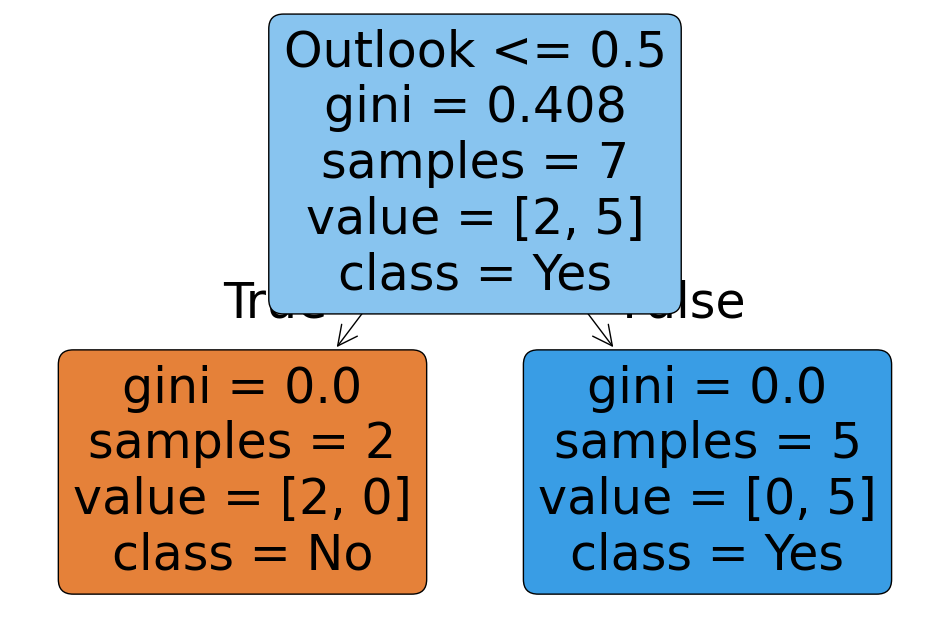

In [32]:
plt.figure(figsize = (12, 8))

plot_tree(
    model,
    feature_names = ['Outlook', 'Temperature', 'Humidity', 'Wind'],
    class_names = ['No', 'Yes'],
    filled = True,
    rounded = True
)

plt.show()